In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## Seasonal Cycles of NDVI, ET, Albedo, and LST of different Forest Classes in Bavaria

In [1]:
import ee
import matplotlib.pyplot as plt
import ee
import datetime  
import matplotlib.pyplot as plt
import geemap
import numpy as np

PROJECT_NAME='xxx'
ee.Initialize(project=PROJECT_NAME)

ASSET="xxx" # insert path
bayern = ee.FeatureCollection(ASSET)

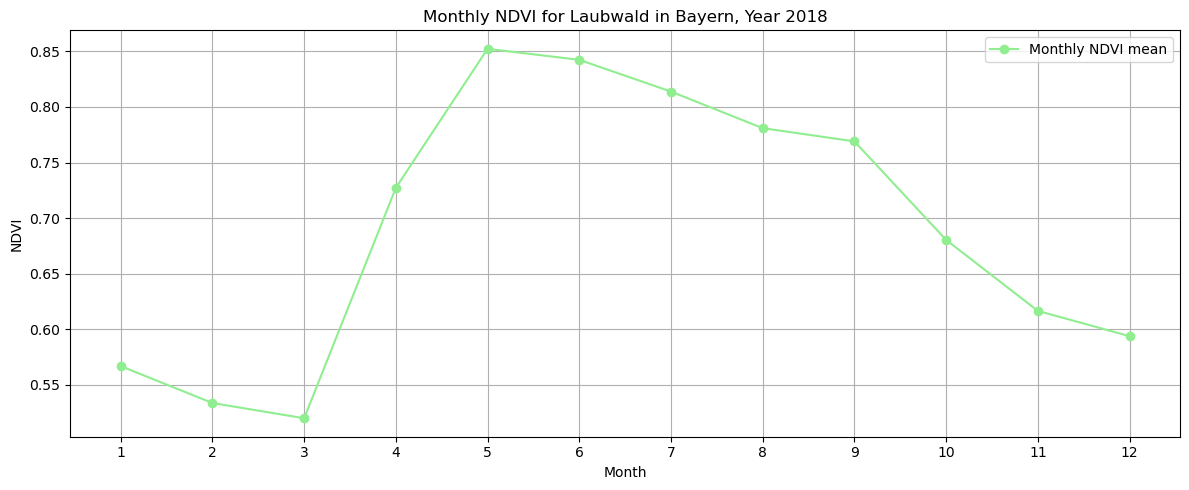

In [3]:
# Testcurve monthly mean - Broadleaf 2018


year = 2018


def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)  # Bits 0 und 1 = 00 (gute Qualität)
    return image.updateMask(mask).select('NDVI')

NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI)

# Landcover Class
lc = ee.ImageCollection("COPERNICUS/CORINE/V20/100m") \
        .filterDate('2017-01-01', '2018-01-01') \
        .first() \
        .select('landcover')

laub = lc.eq(311)

NDVI_laub = NDVI.map(lambda img: img.updateMask(laub))


# Mothly Mean
def monthly_mean(year, month, region):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    mean = (
        NDVI_laub.filterBounds(region)
            .filterDate(start, end)
            .mean()
            .multiply(0.0001)
    )

    
    value = mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region.geometry(),
        scale=250,
        bestEffort=True
    ).get("NDVI")

    return ee.Feature(None, {"month": month, "NDVI": value})



def get_monthly_values(year, region):
    features = []

    for month in range(1, 13):
        features.append(monthly_mean(year, month, region))

    fc = ee.FeatureCollection(features)
    return fc.aggregate_array("NDVI").getInfo()



NDVI_months = get_monthly_values(year, bayern)


# Plot
months = list(range(1, 13))

plt.figure(figsize=(12,5))
plt.plot(months, NDVI_months, marker='o', color='lightgreen', label='Monthly NDVI mean')
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.title(f"Monthly NDVI for Laubwald in Bayern, Year {year}")
plt.xticks(months)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


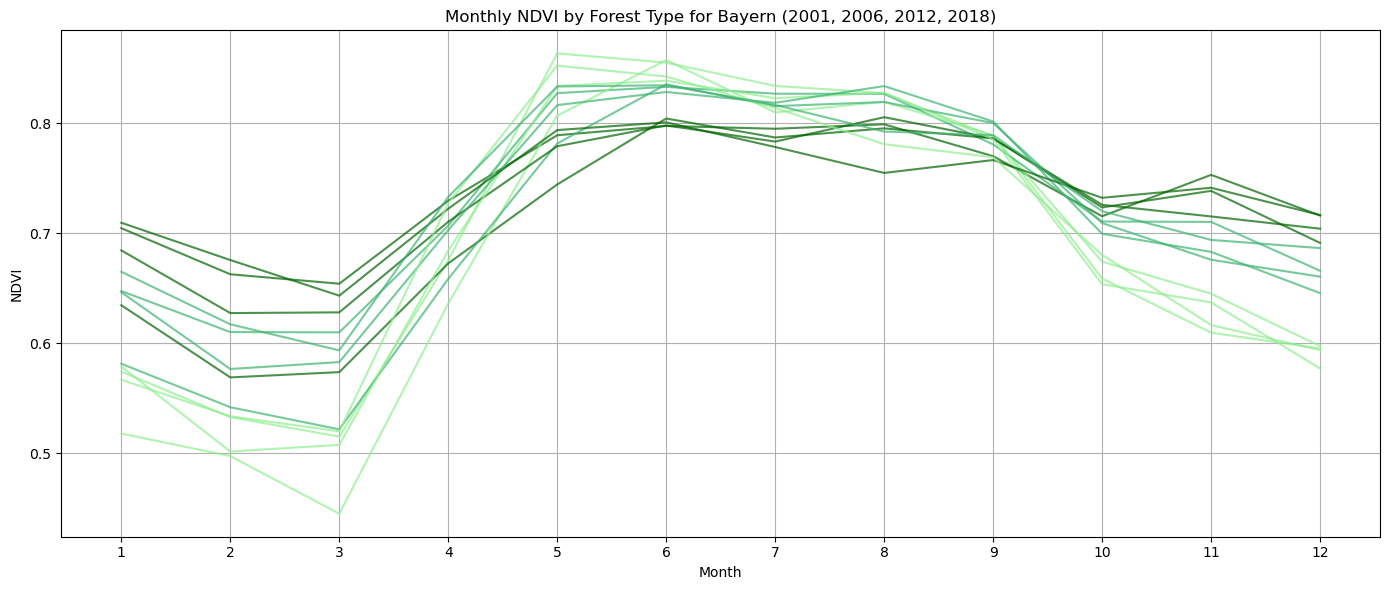

In [20]:
#### NDVI Seasonal Cycle Curves of Broadleaf, Needleleaf, and Mixed - 2001, 2006, 2012, 2018


def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select('NDVI')

NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI)

# Monthly mean
def ndvi_by_class(year, region, lc, lc_class):

    mask = lc.eq(lc_class)
    NDVI_masked = NDVI.map(lambda img: img.updateMask(mask))

    monthly_vals = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, "month")

        mean = (
            NDVI_masked
            .filterDate(start, end)
            .mean()
            .multiply(0.0001)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("NDVI")

        monthly_vals.append(v)

    return ee.Array(monthly_vals).getInfo()


corine_years = [2000, 2006, 2012, 2018]

# 2000 no MODIS data -> MODIS 2001 for CORINE 2000
modis_year_for_corine = {
    2000: 2001,
    2006: 2006,
    2012: 2012,
    2018: 2018
}
months = list(range(1, 13))

# Plot
plt.figure(figsize=(14,6))

for corine_year in corine_years:

    modis_year = modis_year_for_corine[corine_year]

    lc = ee.Image(f"COPERNICUS/CORINE/V20/100m/{corine_year}").select("landcover")

    ndvi_laub  = ndvi_by_class(modis_year, bayern, lc, 311)
    ndvi_nadel = ndvi_by_class(modis_year, bayern, lc, 312)
    ndvi_misch = ndvi_by_class(modis_year, bayern, lc, 313)

    plt.plot(months, ndvi_nadel, color="darkgreen", alpha=0.7)
    plt.plot(months, ndvi_laub,  color="lightgreen", alpha=0.7)
    plt.plot(months, ndvi_misch, color="mediumseagreen", alpha=0.7)

plt.xlabel("Month")
plt.ylabel("NDVI")
plt.title("Monthly NDVI by Forest Type for Bayern (2001, 2006, 2012, 2018)")
plt.xticks(months)
plt.grid(True)
plt.tight_layout()
plt.show()


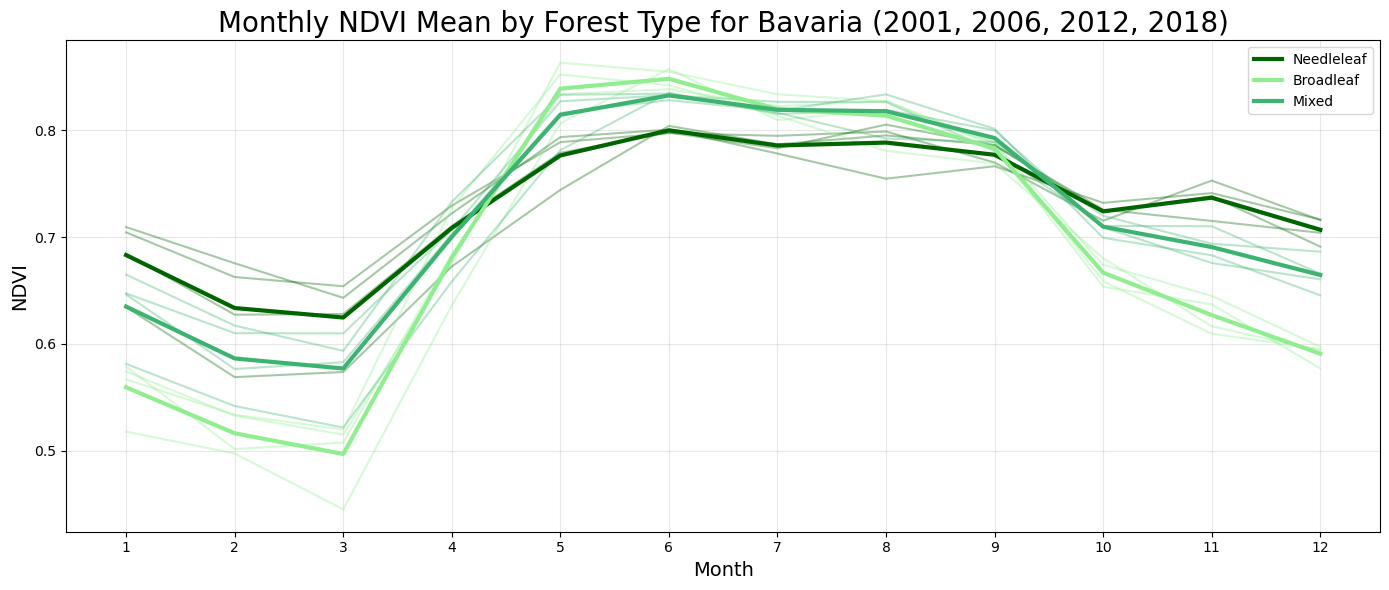

In [3]:
### NDVI Seasonal Cycle Curves of Broadleaf, Needleleaf, and Mixed - 2001, 2006, 2012, 2018



def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select('NDVI')

NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI)

# Monthly Mean
def ndvi_by_class(year, region, lc, lc_class):

    mask = lc.eq(lc_class)
    NDVI_masked = NDVI.map(lambda img: img.updateMask(mask))

    monthly_vals = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, "month")

        mean = (
            NDVI_masked
            .filterDate(start, end)
            .mean()
            .multiply(0.0001)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("NDVI")

        monthly_vals.append(v)

    return ee.Array(monthly_vals).getInfo()


corine_years = [2000, 2006, 2012, 2018]

# 2000 no MODIS data -> MODIS 2001 for CORINE 2000
modis_year_for_corine = {
    2000: 2001,
    2006: 2006,
    2012: 2012,
    2018: 2018
}
months = list(range(1, 13))

nadel_all = []
laub_all  = []
misch_all = []

# Plot
plt.figure(figsize=(14,6))

for corine_year in corine_years:

    modis_year = modis_year_for_corine[corine_year]

    lc = ee.Image(f"COPERNICUS/CORINE/V20/100m/{corine_year}").select("landcover")

    ndvi_laub  = ndvi_by_class(modis_year, bayern, lc, 311)
    ndvi_nadel = ndvi_by_class(modis_year, bayern, lc, 312)
    ndvi_misch = ndvi_by_class(modis_year, bayern, lc, 313)

    laub_all.append(ndvi_laub)
    nadel_all.append(ndvi_nadel)
    misch_all.append(ndvi_misch)

    plt.plot(months, ndvi_nadel, color="darkgreen", alpha=0.35)
    plt.plot(months, ndvi_laub,  color="lightgreen", alpha=0.35)
    plt.plot(months, ndvi_misch, color="mediumseagreen", alpha=0.35)

# Mean across all years
mean_nadel = np.mean(nadel_all, axis=0)
mean_laub  = np.mean(laub_all, axis=0)
mean_misch = np.mean(misch_all, axis=0)

plt.plot(months, mean_nadel, color="darkgreen", linewidth=3, label="Needleleaf")
plt.plot(months, mean_laub,  color="lightgreen", linewidth=3, label="Broadleaf")
plt.plot(months, mean_misch, color="mediumseagreen", linewidth=3, label="Mixed")

plt.xlabel("Month", fontsize=14)
plt.ylabel("NDVI", fontsize=14)
plt.title("Monthly NDVI Mean by Forest Type for Bavaria (2001, 2006, 2012, 2018)", fontsize=20)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


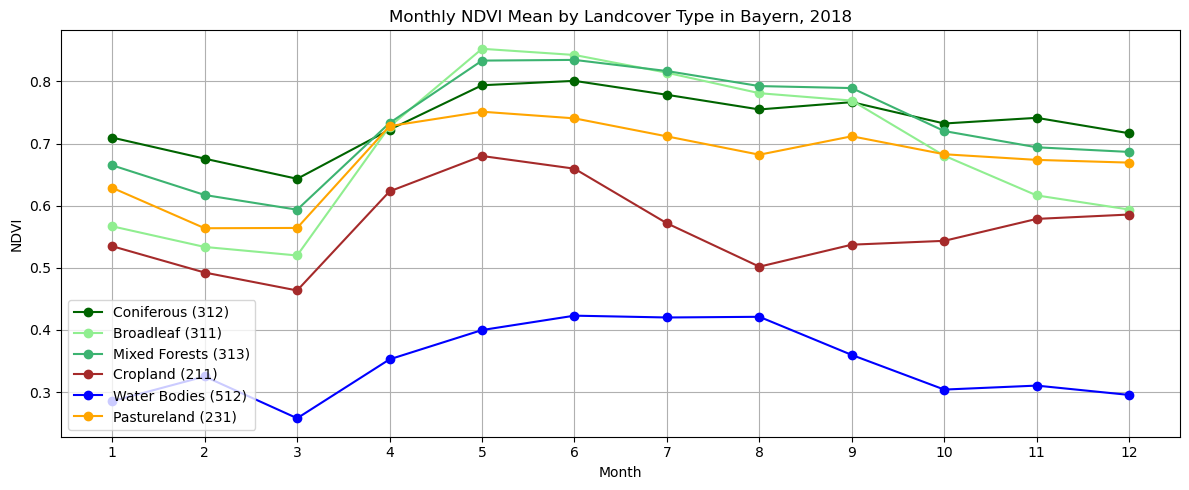

In [8]:
### NDVI Seasonal Cycle Curves - Other LCC 2018


year = 2018

def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)  
    return image.updateMask(mask).select('NDVI')

NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI)


lc = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# NDVI by LCC
def ndvi_by_class(year, region, lc_class):
    
    mask = lc.eq(lc_class)
    
    NDVI_masked = NDVI.map(lambda img: img.updateMask(mask))

    monthly_vals = []
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")

        mean = (
            NDVI_masked
            .filterBounds(region)
            .filterDate(start, end)
            .mean()
            .multiply(0.0001)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("NDVI")

        monthly_vals.append(v)

    # Convert to Python list
    return ee.Array(monthly_vals).getInfo()
    

# NDVI per class
ndvi_laub = ndvi_by_class(year, bayern, 311)  
ndvi_nadel = ndvi_by_class(year, bayern, 312) 
ndvi_mixed = ndvi_by_class(year, bayern, (313))

ndvi_cropland = ndvi_by_class(year, bayern, 211)
ndvi_water = ndvi_by_class(year, bayern, 512)
ndvi_gras = ndvi_by_class(year, bayern, (231))


# Plot
months = list(range(1, 13))

plt.figure(figsize=(12,5))
plt.plot(months, ndvi_nadel, marker='o', color='darkgreen', label='Coniferous (312)')
plt.plot(months, ndvi_laub, marker='o', color='lightgreen', label='Broadleaf (311)')
plt.plot(months, ndvi_mixed, marker='o', color='mediumseagreen', label='Mixed Forests (313)')
plt.plot(months, ndvi_cropland, marker='o', color='brown', label='Cropland (211)')
plt.plot(months, ndvi_water, marker='o', color='blue', label='Water Bodies (512)')
plt.plot(months, ndvi_gras, marker='o', color='orange', label='Pastureland (231)')

plt.xlabel("Month")
plt.ylabel("NDVI")
plt.title(f"Monthly NDVI Mean by Landcover Type in Bayern, {year}")
plt.xticks(months)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

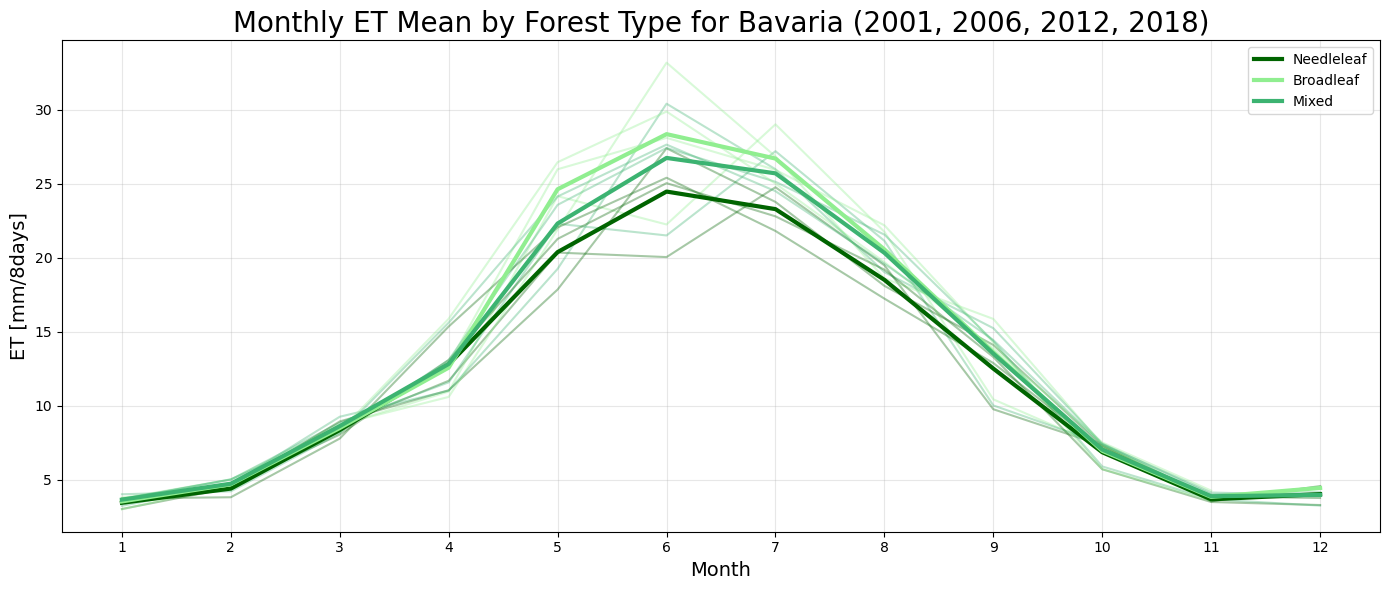

In [4]:
### ET Seasonal Cycle Curves of Broadleaf, Needleleaf, and Mixed - 2001, 2006, 2012, 2018


def maskET(image):
    qc = image.select('ET_QC')
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('ET')

ET = (ee.ImageCollection("MODIS/061/MOD16A2GF").map(maskET))

# Monthly Mean
def ET_by_class(year, region, lc, lc_class):

    mask = lc.eq(lc_class)
    ET_masked = ET.map(lambda img: img.updateMask(mask))

    monthly_vals = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, "month")

        mean = (
            ET_masked
            .filterDate(start, end)
            .mean()
            .multiply(0.1)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=500,
            bestEffort=True
        ).get("ET")

        monthly_vals.append(v)

    return ee.List(monthly_vals).getInfo()


corine_years = [2000, 2006, 2012, 2018]

# 2000 no MODIS data -> MODIS 2001 for CORINE 2000
modis_year_for_corine = {
    2000: 2001,
    2006: 2006,
    2012: 2012,
    2018: 2018
}
months = list(range(1, 13))

nadel_all = []
laub_all  = []
misch_all = []

# Plot
plt.figure(figsize=(14,6))

for corine_year in corine_years:

    modis_year = modis_year_for_corine[corine_year]

    lc = ee.Image(f"COPERNICUS/CORINE/V20/100m/{corine_year}").select("landcover")

    ET_laub  = ET_by_class(modis_year, bayern, lc, 311)
    ET_nadel = ET_by_class(modis_year, bayern, lc, 312)
    ET_misch = ET_by_class(modis_year, bayern, lc, 313)

    ET_laub = np.array([v if v is not None else np.nan for v in ET_laub])
    ET_nadel = np.array([v if v is not None else np.nan for v in ET_nadel])
    ET_misch = np.array([v if v is not None else np.nan for v in ET_misch])


    laub_all.append(ET_laub)
    nadel_all.append(ET_nadel)
    misch_all.append(ET_misch)

    plt.plot(months, ET_nadel, color="darkgreen", alpha=0.35)
    plt.plot(months, ET_laub,  color="lightgreen", alpha=0.35)
    plt.plot(months, ET_misch, color="mediumseagreen", alpha=0.35)

# Mean across all years
mean_nadel = np.nanmean(nadel_all, axis=0)
mean_laub  = np.nanmean(laub_all, axis=0)
mean_misch = np.nanmean(misch_all, axis=0)

plt.plot(months, mean_nadel, color="darkgreen", linewidth=3, label="Needleleaf")
plt.plot(months, mean_laub,  color="lightgreen", linewidth=3, label="Broadleaf")
plt.plot(months, mean_misch, color="mediumseagreen", linewidth=3, label="Mixed")

plt.xlabel("Month", fontsize=14)
plt.ylabel("ET [mm/8days]", fontsize=14)
plt.title("Monthly ET Mean by Forest Type for Bavaria (2001, 2006, 2012, 2018)", fontsize=20)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


[4.130343905177718, 4.398723215227913, 8.331491235500945, 14.933852326734042, 21.532110439370665, 24.595580800284228, 18.254353598791752, 12.253151733394322, 9.523606389531155, 6.528582703610853, 4.473088244850537, None]


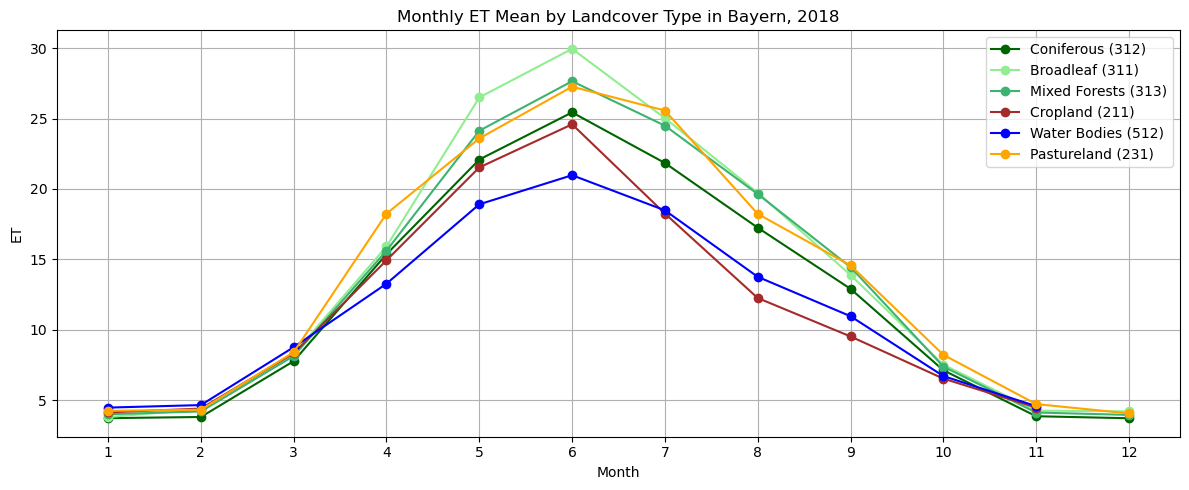

In [10]:
### ET Seasonal Cycle Curves - Other LCC 2018


year = 2018

def maskET(image):
    qc = image.select('ET_QC')
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('ET')

ET = (ee.ImageCollection("MODIS/061/MOD16A2GF").map(maskET))
      


lc = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# ET by LCC
def ET_by_class(year, region, lc_class):
    
    mask = lc.eq(lc_class)
    
    ET_masked = ET.map(lambda img: img.updateMask(mask))

    monthly_vals = []
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")

        mean = (
            ET_masked
            .filterBounds(region)
            .filterDate(start, end)
            .mean()
            .multiply(0.1)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("ET")


        monthly_vals.append(v)
       

    # Convert to Python list
    return ee.List(monthly_vals).getInfo()
    

# NDVI per class
ET_laub = ET_by_class(year, bayern, 311)  
ET_nadel = ET_by_class(year, bayern, 312) 
ET_mixed = ET_by_class(year, bayern, (313))

ET_cropland = ET_by_class(year, bayern, 211)              # No december value
print (ET_cropland)
# remove None
vals_clean = [v for v in ET_cropland if v is not None]


months_clean = [m for m, v in zip(range(1, 13), ET_cropland) if v is not None]

ET_water = ET_by_class(year, bayern, 512)
ET_gras = ET_by_class(year, bayern, (231))


# Plot
months = list(range(1, 13))

plt.figure(figsize=(12,5))
plt.plot(months, ET_nadel, marker='o', color='darkgreen', label='Coniferous (312)')
plt.plot(months, ET_laub, marker='o', color='lightgreen', label='Broadleaf (311)')
plt.plot(months, ET_mixed, marker='o', color='mediumseagreen', label='Mixed Forests (313)')
plt.plot(months_clean, vals_clean, marker='o', color='brown', label='Cropland (211)')
plt.plot(months, ET_water, marker='o', color='blue', label='Water Bodies (512)')
plt.plot(months, ET_gras, marker='o', color='orange', label='Pastureland (231)')

plt.xlabel("Month")
plt.ylabel("ET")
plt.title(f"Monthly ET Mean by Landcover Type in Bayern, {year}")
plt.xticks(months)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

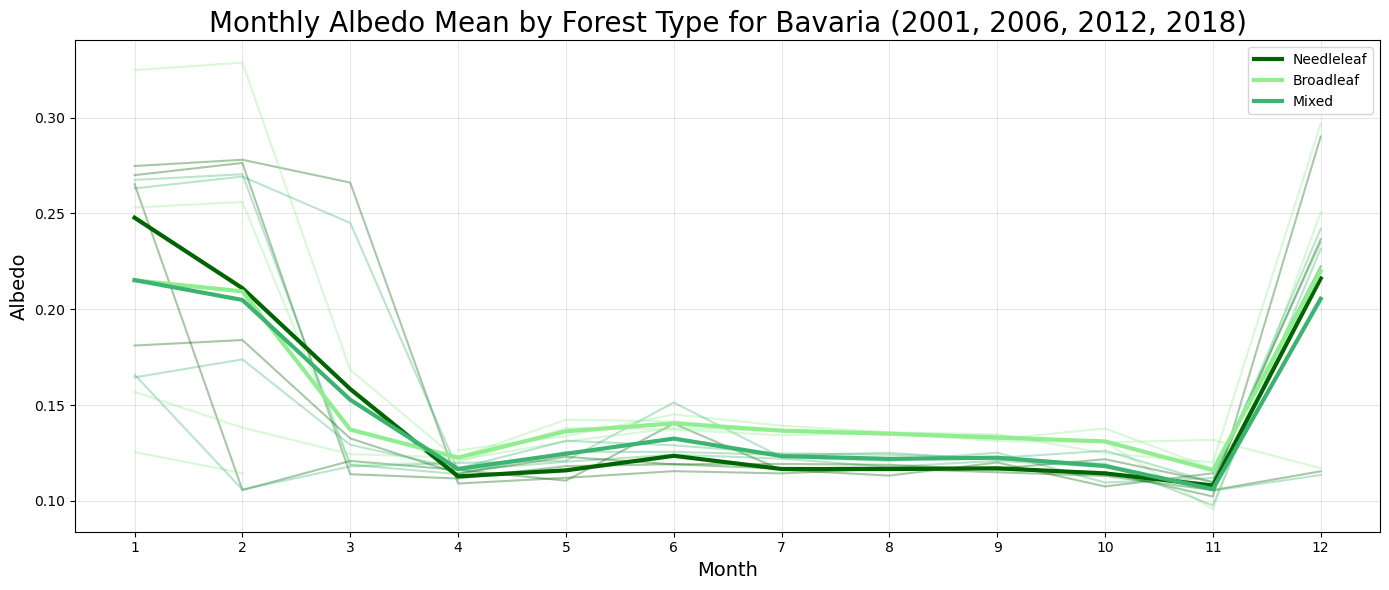

In [5]:
### Albedo Seasonal Cycle Curves of Broadleaf, Needleleaf, and Mixed - 2001, 2006, 2012, 2018


def maskALB(image):
    qc = image.select('BRDF_Albedo_Band_Mandatory_Quality_shortwave')
    # bitwiseAnd(1) betrachtet Bit 0
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('Albedo_BSA_shortwave')

ALB = (ee.ImageCollection("MODIS/061/MCD43A3").map(maskALB))

# Monthly Mean
def ALB_by_class(year, region, lc, lc_class):

    mask = lc.eq(lc_class)
    ALB_masked = ALB.map(lambda img: img.updateMask(mask))

    monthly_vals = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, "month")

        mean = (
            ALB_masked
            .filterDate(start, end)
            .mean()
            .multiply(0.001)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=500,
            bestEffort=True
        ).get("Albedo_BSA_shortwave")

        monthly_vals.append(v)

    return ee.List(monthly_vals).getInfo()


corine_years = [2000, 2006, 2012, 2018]

# 2000 no MODIS data -> MODIS 2001 for CORINE 2000
modis_year_for_corine = {
    2000: 2001,
    2006: 2006,
    2012: 2012,
    2018: 2018
}
months = list(range(1, 13))

nadel_all = []
laub_all  = []
misch_all = []

# Plot
plt.figure(figsize=(14,6))

for corine_year in corine_years:

    modis_year = modis_year_for_corine[corine_year]

    lc = ee.Image(f"COPERNICUS/CORINE/V20/100m/{corine_year}").select("landcover")

    ALB_laub  = ALB_by_class(modis_year, bayern, lc, 311)
    ALB_nadel = ALB_by_class(modis_year, bayern, lc, 312)
    ALB_misch = ALB_by_class(modis_year, bayern, lc, 313)

    ALB_laub = np.array([v if v is not None else np.nan for v in ALB_laub])
    ALB_nadel = np.array([v if v is not None else np.nan for v in ALB_nadel])
    ALB_misch = np.array([v if v is not None else np.nan for v in ALB_misch])

    laub_all.append(ALB_laub)
    nadel_all.append(ALB_nadel)
    misch_all.append(ALB_misch)

    plt.plot(months, ALB_nadel, color="darkgreen", alpha=0.35)
    plt.plot(months, ALB_laub,  color="lightgreen", alpha=0.35)
    plt.plot(months, ALB_misch, color="mediumseagreen", alpha=0.35)

# Mean across all years
mean_nadel = np.nanmean(nadel_all, axis=0)
mean_laub  = np.nanmean(laub_all, axis=0)
mean_misch = np.nanmean(misch_all, axis=0)

plt.plot(months, mean_nadel, color="darkgreen", linewidth=3, label="Needleleaf")
plt.plot(months, mean_laub,  color="lightgreen", linewidth=3, label="Broadleaf")
plt.plot(months, mean_misch, color="mediumseagreen", linewidth=3, label="Mixed")

plt.xlabel("Month", fontsize=14)
plt.ylabel("Albedo", fontsize=14)
plt.title("Monthly Albedo Mean by Forest Type for Bavaria (2001, 2006, 2012, 2018)", fontsize=20)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


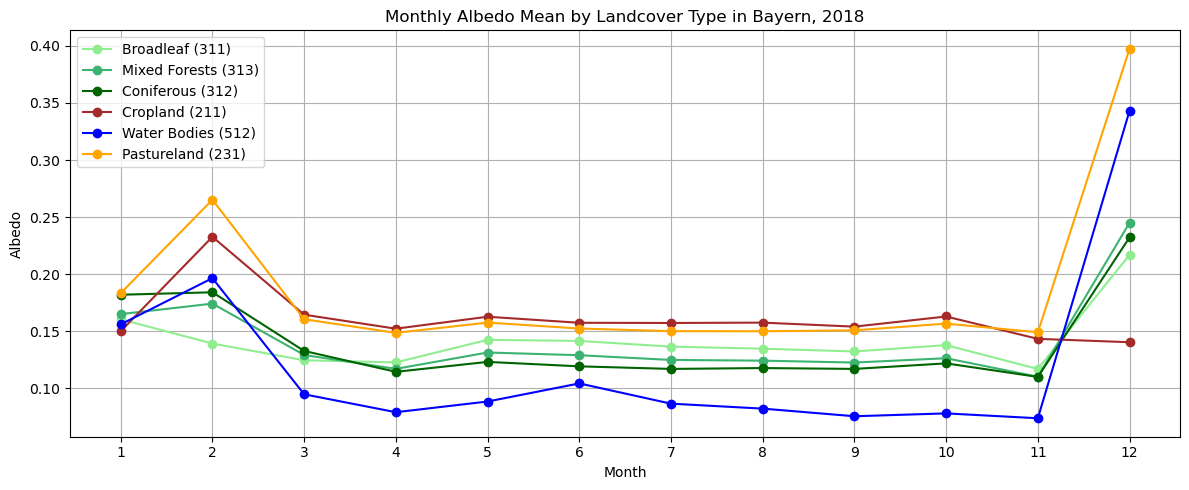

In [14]:
### Albedo Seasonal Cycle Curves - Other LCC 2018


year = 2018                 

def maskALB(image):
    qc = image.select('BRDF_Albedo_Band_Mandatory_Quality_shortwave')
    # bitwiseAnd(1) betrachtet Bit 0
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select('Albedo_BSA_shortwave')

ALB = (ee.ImageCollection("MODIS/061/MCD43A3").map(maskALB))
      


lc = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# Albedo by LCC
def ALB_by_class(year, region, lc_class):
    
    mask = lc.eq(lc_class)
    
    ALB_masked = ALB.map(lambda img: img.updateMask(mask))

    monthly_vals = []
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")

        mean = (
            ALB_masked
            .filterBounds(region)
            .filterDate(start, end)
            .mean()
            .multiply(0.001)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("Albedo_BSA_shortwave")


        monthly_vals.append(v)
       

    # Convert to Python list
    return ee.List(monthly_vals).getInfo()
    

# Albedo per class
ALB_laub = ALB_by_class(year, bayern, 311)  
ALB_nadel = ALB_by_class(year, bayern, 312) 
ALB_mixed = ALB_by_class(year, bayern, 313)

ALB_cropland = ALB_by_class(year, bayern, 211)
ALB_water = ALB_by_class(year, bayern, 512)
ALB_gras = ALB_by_class(year, bayern, 231)


# Plot
months = list(range(1, 13))

plt.figure(figsize=(12,5))
plt.plot(months, ALB_laub, marker='o', color='lightgreen', label='Broadleaf (311)')
plt.plot(months, ALB_mixed, marker='o', color='mediumseagreen', label='Mixed Forests (313)')
plt.plot(months, ALB_nadel, marker='o', color='darkgreen', label='Coniferous (312)')
plt.plot(months, ALB_cropland, marker='o', color='brown', label='Cropland (211)')
plt.plot(months, ALB_water, marker='o', color='blue', label='Water Bodies (512)')
plt.plot(months, ALB_gras, marker='o', color='orange', label='Pastureland (231)')
plt.xlabel("Month")
plt.ylabel("Albedo")
plt.title(f"Monthly Albedo Mean by Landcover Type in Bayern, {year}")
plt.xticks(months)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

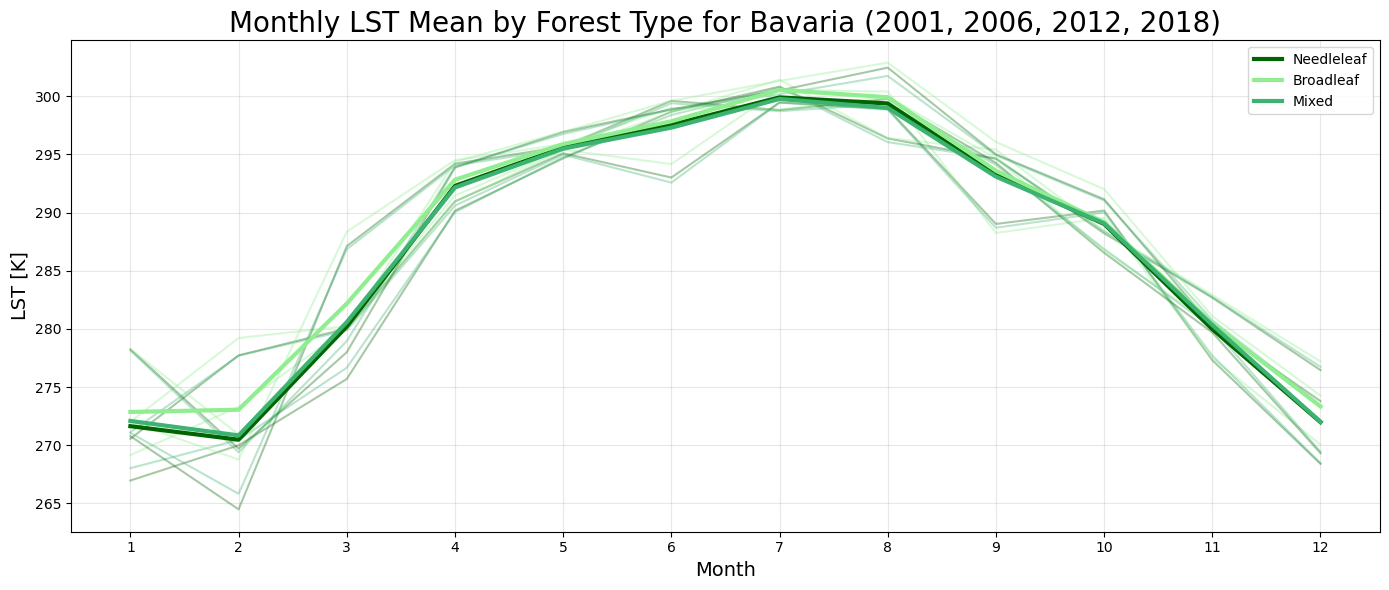

In [6]:
### LST Seasonal Cycle Curves of Broadleaf, Needleleaf, and Mixed - 2001, 2006, 2012, 2018


def maskLST(image):
    qc = image.select('QC_Day')
    # bitwiseAnd(3) -> dezimalzahl 3 sind bits 0 und 1 -> 1 + 2
    mask = qc.bitwiseAnd(3).eq(0) # Bits 0 und 1 sind 00 -> good quality
    return image.updateMask(mask).select('LST_Day_1km')

LST = (ee.ImageCollection("MODIS/061/MOD11A1").map(maskLST))

# Monthly Mean
def LST_by_class(year, region, lc, lc_class):

    mask = lc.eq(lc_class)
    LST_masked = LST.map(lambda img: img.updateMask(mask))

    monthly_vals = []

    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end   = start.advance(1, "month")

        mean = (
            LST_masked
            .filterDate(start, end)
            .mean()
            .multiply(0.02)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=1000,
            bestEffort=True
        ).get("LST_Day_1km")

        monthly_vals.append(v)

    return ee.List(monthly_vals).getInfo()


corine_years = [2000, 2006, 2012, 2018]

# 2000 no MODIS data -> MODIS 2001 for CORINE 2000
modis_year_for_corine = {
    2000: 2001,
    2006: 2006,
    2012: 2012,
    2018: 2018
}
months = list(range(1, 13))

nadel_all = []
laub_all  = []
misch_all = []

# Plot
plt.figure(figsize=(14,6))

for corine_year in corine_years:

    modis_year = modis_year_for_corine[corine_year]

    lc = ee.Image(f"COPERNICUS/CORINE/V20/100m/{corine_year}").select("landcover")

    LST_laub  = LST_by_class(modis_year, bayern, lc, 311)
    LST_nadel = LST_by_class(modis_year, bayern, lc, 312)
    LST_misch = LST_by_class(modis_year, bayern, lc, 313)

    LST_laub = np.array([v if v is not None else np.nan for v in LST_laub])
    LST_nadel = np.array([v if v is not None else np.nan for v in LST_nadel])
    LST_misch = np.array([v if v is not None else np.nan for v in LST_misch])

    laub_all.append(LST_laub)
    nadel_all.append(LST_nadel)
    misch_all.append(LST_misch)

    plt.plot(months, LST_nadel, color="darkgreen", alpha=0.35)
    plt.plot(months, LST_laub,  color="lightgreen", alpha=0.35)
    plt.plot(months, LST_misch, color="mediumseagreen", alpha=0.35)

# Means across years
mean_nadel = np.nanmean(nadel_all, axis=0)
mean_laub  = np.nanmean(laub_all, axis=0)
mean_misch = np.nanmean(misch_all, axis=0)

plt.plot(months, mean_nadel, color="darkgreen", linewidth=3, label="Needleleaf")
plt.plot(months, mean_laub,  color="lightgreen", linewidth=3, label="Broadleaf")
plt.plot(months, mean_misch, color="mediumseagreen", linewidth=3, label="Mixed")

plt.xlabel("Month", fontsize=14)
plt.ylabel("LST [K]", fontsize=14)
plt.title("Monthly LST Mean by Forest Type for Bavaria (2001, 2006, 2012, 2018)", fontsize=20)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


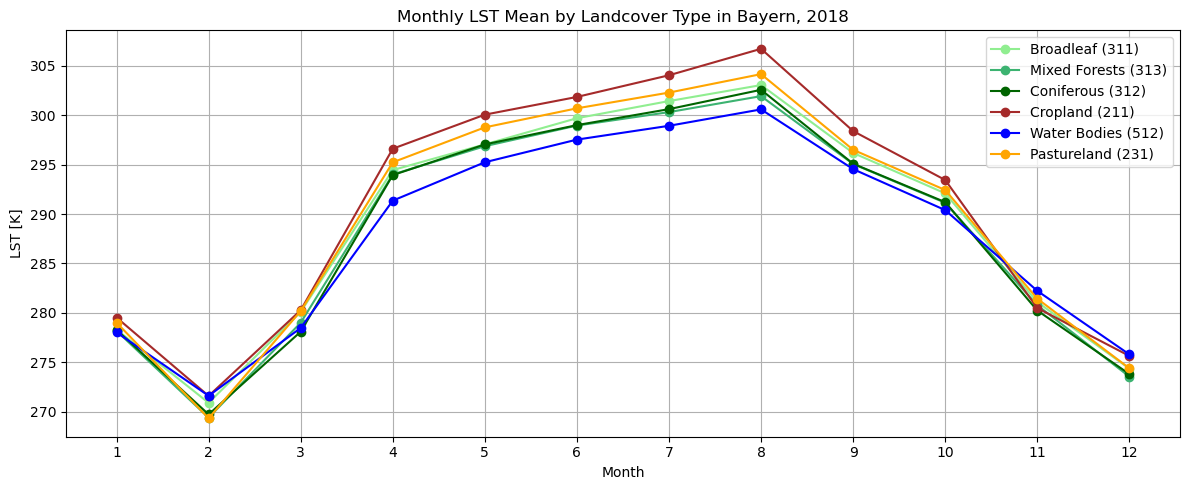

In [16]:
### LST Seasonal Cycle Curves - Other LCC 2018


year = 2018

def maskLST(image):
    qc = image.select('QC_Day')
    # bitwiseAnd(3) -> dezimalzahl 3 sind bits 0 und 1 -> 1 + 2
    mask = qc.bitwiseAnd(3).eq(0) # Bits 0 und 1 sind 00 -> good quality
    return image.updateMask(mask).select('LST_Day_1km')

LST = (ee.ImageCollection("MODIS/061/MOD11A1").map(maskLST))
      


lc = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# LST by LCC
def LST_by_class(year, region, lc_class):
    
    mask = lc.eq(lc_class)
    
    LST_masked = LST.map(lambda img: img.updateMask(mask))

    monthly_vals = []
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, "month")

        mean = (
            LST_masked
            .filterBounds(region)
            .filterDate(start, end)
            .mean()
            .multiply(0.02)
        )

        v = mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region.geometry(),
            scale=250,
            bestEffort=True
        ).get("LST_Day_1km")


        monthly_vals.append(v)
       

    # Convert to Python list
    return ee.List(monthly_vals).getInfo()
    

# LST values per class
LST_laub = LST_by_class(year, bayern, 311)  
LST_nadel = LST_by_class(year, bayern, 312) 
LST_mixed = LST_by_class(year, bayern, 313)

LST_cropland = LST_by_class(year, bayern, 211)
LST_water = LST_by_class(year, bayern, 512)
LST_gras = LST_by_class(year, bayern, 231)

# Plot
months = list(range(1, 13))

plt.figure(figsize=(12,5))
plt.plot(months, LST_laub, marker='o', color='lightgreen', label='Broadleaf (311)')
plt.plot(months, LST_mixed, marker='o', color='mediumseagreen', label='Mixed Forests (313)')
plt.plot(months, LST_nadel, marker='o', color='darkgreen', label='Coniferous (312)')
plt.plot(months, LST_cropland, marker='o', color='brown', label='Cropland (211)')
plt.plot(months, LST_water, marker='o', color='blue', label='Water Bodies (512)')
plt.plot(months, LST_gras, marker='o', color='orange', label='Pastureland (231)')
plt.xlabel("Month")
plt.ylabel("LST [K]")
plt.title(f"Monthly LST Mean by Landcover Type in Bayern, {year}")
plt.xticks(months)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()